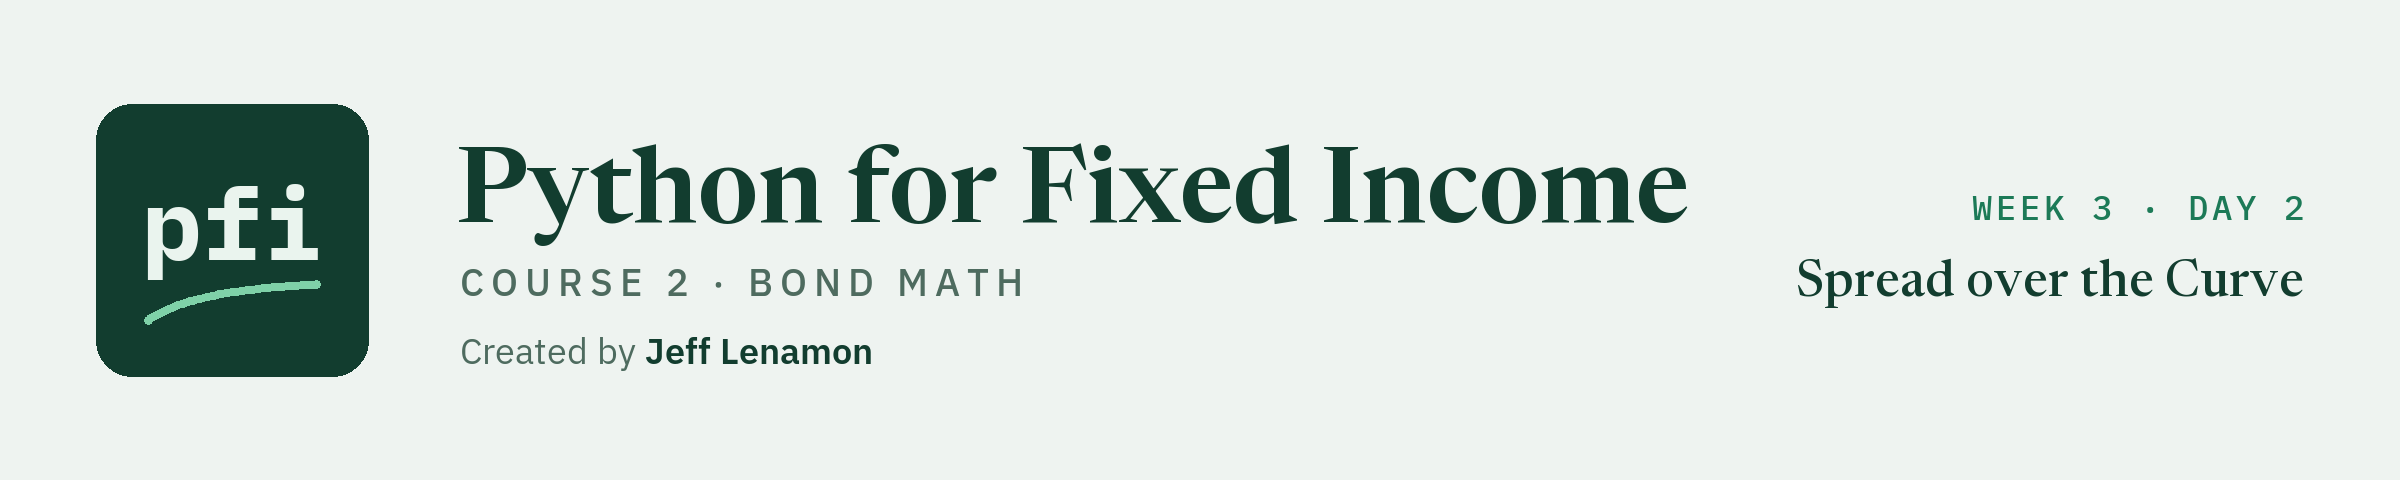

# Spread over the Curve

Week 3, Day 2. Every bond's yield spread to the curve at its own maturity, in basis points: years to maturity on 30/360, the curve yield there, the holdings file's `oas` column reproduced exactly with the curve's formula, and how far a straight line between ten tenors moves the answer.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week3/day2/12_spread_over_the_curve.ipynb)

Day 11 read a curve: tenors, yields, and a straight line between them, in `interpolate_yield`. It also met the invented curve the holdings file was built on, at ten tenors in `course2_treasury_curve.csv`.

Today puts a bond on that curve. The holdings file has a column called `oas`: for the first bond, Bezane Finance's 2032 bond, it says **147**. That number is a spread, in basis points, of the bond's yield over the curve at the bond's own maturity. Today you rebuild it for all 200 bonds, and you find out exactly how the file built it.

Today you will:

1. Say what the spread measures in this file, and work one bond by hand.
2. Count the years to maturity on 30/360, the rule the file used, with `years_to_maturity`, and match Excel's `YEARFRAC`.
3. Read the curve at each bond's maturity, with day 11's `interpolate_yield` and Excel's `FORECAST.LINEAR`.
4. Add `spread_to_curve_bp` to your module.
5. Reproduce the `oas` column exactly, with the curve's own formula.
6. Do the same with the ten-tenor table, and measure the gap. That gap is the lesson of the day.
7. Name the number correctly: what `oas` means in this file, and what it means on a desk.

The issuers are invented, and so is every number. A spread here describes the data: nothing below says a bond or a rating bucket is good value or poor value.

The setup cell is the same as every day. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 11.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_12_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_12_jizakktt, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]


BASIS = {"0": "30/360", "1": "ACT/ACT"}  # Excel's basis number to bondmath's name


def bond_inputs(row: dict) -> tuple:
    """settlement, maturity, coupon_pct, yield_pct, frequency, basis from a reference row, in bondmath's units."""
    return (date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"]),
            float(row["coupon_pct"]), float(row["yield_pct"]), int(row["frequency"]), BASIS[row["basis"]])


def test_days_30_360_rule_cases():
    # (start, end, expected days, the Excel function that confirms the value)
    cases = [
        (date(2026, 8, 16), date(2026, 9, 30), 44, "COUPDAYBS"),    # no rule applies
        (date(2027, 2, 28), date(2027, 3, 1), 1, "COUPDAYBS"),      # rule 1: last day of February counts as 30
        (date(2027, 2, 28), date(2028, 2, 29), 360, "YEARFRAC"),    # rule 2: both on the last day of February
        (date(2026, 8, 31), date(2026, 9, 30), 30, "COUPDAYBS"),    # rule 3: a 31st start counts as 30
        (date(2026, 7, 30), date(2026, 10, 31), 90, "COUPDAYBS"),   # rule 4: a 31st end after a 30th start
        (date(2026, 10, 15), date(2026, 10, 31), 16, "COUPDAYBS"),  # a 31st end after a 15th start stays 31
        (date(2027, 2, 28), date(2027, 3, 31), 31, "COUPDAYBS"),    # rule 1, and the 31st end stays 31
        (date(2026, 11, 15), date(2027, 2, 28), 103, "COUPDAYBS"),  # an end on 28 February is not changed
    ]
    for start, end, expected, source in cases:
        assert bondmath.days_30_360(start, end) == expected, (start, end)
        if source == "COUPDAYBS":
            # the same pair of dates appears in the reference file as previous coupon and settlement
            matches = [row for row in REFERENCE if row["basis"] == "0" and row["couppcd"] == start.isoformat()
                       and row["settlement"] == end.isoformat()]
            assert matches, f"no reference row with previous coupon {start} and settlement {end}"
            assert int(matches[0]["coupdaybs"]) == expected
        # the YEARFRAC value, YEARFRAC(start, end, 0) x 360 = 360, was checked in Excel by the reference tool


def test_coupon_period_days_match_excel():
    for row in REFERENCE:
        settlement, maturity, _, _, frequency, basis = bond_inputs(row)
        days_accrued, days_in_period, days_to_next = bondmath.coupon_period_days(settlement, maturity, frequency, basis)
        # A is COUPDAYBS under both bases
        assert days_accrued == int(row["coupdaybs"]), row["case_id"]
        if basis == "30/360":
            # E is COUPDAYS, and PRICE uses DSC = E - A
            assert days_in_period == int(row["coupdays"]), row["case_id"]
            assert days_to_next == int(row["coupdays"]) - int(row["coupdaybs"]), row["case_id"]
        else:
            # E is the actual length of the period, which PRICE uses (Excel's COUPDAYS with basis 1 can differ)
            period_start, period_end = date.fromisoformat(row["couppcd"]), date.fromisoformat(row["coupncd"])
            assert days_in_period == (period_end - period_start).days, row["case_id"]
            assert days_to_next == int(row["coupdaysnc"]), row["case_id"]


def test_accrued_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        result = bondmath.accrued_interest(settlement, maturity, coupon_pct, frequency, basis)
        assert result == pytest.approx(float(row["accrued"]), abs=1e-9), row["case_id"]


def test_price_matches_excel():
    for row in REFERENCE:
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_dirty_is_clean_plus_accrued():
    for row in REFERENCE:
        result = bondmath.dirty_price(*bond_inputs(row))
        # Excel's PRICE plus Excel's accrued formula
        assert result == pytest.approx(float(row["price"]) + float(row["accrued"]), abs=1e-6), row["case_id"]


def test_price_on_coupon_date_equals_week1():
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        settlement, maturity, coupon_pct, yield_pct, frequency, basis = bond_inputs(row)
        # on a coupon date the bond has a whole number of periods left
        years = int(row["coupnum"]) / frequency
        week1_price = bondmath.price_from_yield(coupon_pct, yield_pct, years, frequency)
        assert bondmath.price(settlement, maturity, coupon_pct, yield_pct, frequency, basis) == pytest.approx(
            week1_price, abs=1e-9), row["case_id"]


def test_final_period_matches_excel():
    final_period_rows = [row for row in REFERENCE if row["coupnum"] == "1"]
    assert final_period_rows, "no final-period rows in the reference file"
    for row in final_period_rows:
        # one coupon left: Excel prices it with simple interest
        result = bondmath.price(*bond_inputs(row))
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_yield_to_maturity_matches_excel():
    for row in REFERENCE:
        settlement, maturity, coupon_pct, _, frequency, basis = bond_inputs(row)
        # solve the yield from Excel's price, and compare with Excel's YIELD of that price
        result = bondmath.yield_to_maturity(settlement, maturity, coupon_pct, float(row["price"]), frequency, basis)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_macaulay_matches_excel_duration():
    for row in REFERENCE:
        result = bondmath.macaulay_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["duration"]), abs=1e-6), row["case_id"]


def test_modified_matches_excel_mduration():
    for row in REFERENCE:
        result = bondmath.modified_duration(*bond_inputs(row))
        assert result == pytest.approx(float(row["mduration"]), abs=1e-6), row["case_id"]


def test_dv01_matches_excel_formula():
    for row in REFERENCE:
        result = bondmath.dv01(*bond_inputs(row))
        # Excel: MDURATION x (PRICE + accrued) / 10000
        assert result == pytest.approx(float(row["dv01"]), abs=1e-8), row["case_id"]


def test_dv01_close_to_bump():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: simple interest, so the bump is not the same measure
        # Excel's PRICE 1 bp lower and 1 bp higher, half the difference
        bump = (float(row["price_down_1bp"]) - float(row["price_up_1bp"])) / 2
        assert bondmath.dv01(*bond_inputs(row)) == pytest.approx(bump, abs=1e-6), row["case_id"]


def test_convexity_matches_excel_finite_difference():
    for row in REFERENCE:
        if row["coupnum"] == "1":
            continue  # final period: Excel prices it with simple interest, so its curvature is not comparable
        # Excel: (PRICE(y+h) + PRICE(y-h) - 2 PRICE(y)) / ((PRICE(y) + accrued) h^2), with h = 1 bp
        result = bondmath.convexity(*bond_inputs(row))
        assert result == pytest.approx(float(row["convexity_fd"]), abs=1e-3), row["case_id"]


# The invented curve the holdings file was built on, at ten tenors: round(3.55 + 1.05 x (1 - exp(-T / 7)), 3)
CURVE_TENORS = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
CURVE_YIELDS_PCT = [3.587, 3.622, 3.69, 3.811, 3.916, 4.086, 4.214, 4.348, 4.54, 4.586]


def test_on_a_tenor_returns_its_yield():
    for tenor, yield_pct in zip(CURVE_TENORS, CURVE_YIELDS_PCT):
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(yield_pct, abs=1e-12)


def test_matches_numpy_interp():
    import numpy as np  # numpy is in the course requirements; bondmath itself does not use it

    for tenor in (0.1, 0.92, 1.5, 4.0, 6.4, 8.75, 15.0, 29.9, 35.0):
        expected = float(np.interp(tenor, CURVE_TENORS, CURVE_YIELDS_PCT))
        assert bondmath.interpolate_yield(tenor, CURVE_TENORS, CURVE_YIELDS_PCT) == pytest.approx(expected, abs=1e-12)


def test_flat_beyond_the_ends():
    # below the first tenor: the first yield; above the last: the last yield
    assert bondmath.interpolate_yield(0.1, CURVE_TENORS, CURVE_YIELDS_PCT) == 3.587
    assert bondmath.interpolate_yield(40, CURVE_TENORS, CURVE_YIELDS_PCT) == 4.586


def test_raises_when_tenors_not_ascending():
    with pytest.raises(ValueError):
        bondmath.interpolate_yield(4, [1, 3, 2], [3.7, 3.9, 3.8])

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates', 'days_30_360', 'coupon_period_days', 'accrued_interest', 'price', 'dirty_price', 'yield_to_maturity', 'macaulay_duration', 'modified_duration', 'dv01', 'convexity', 'interpolate_yield']


* The two files exactly as day 11 left them: 19 functions and 32 tests. By the end of today there will be 21 functions and 35 tests.

Today's Git step compares the files with the end of week 2, so the work folder needs a history with the tags `week1` and `week2` in it. Your own `my_bondmath` folder has that history already: you tagged it on days 5 and 10. This work folder is new today, so the next cells rebuild a short version of it from the start-of-day files.

Q. Make the work folder a repository.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_12_jizakktt and nowhere else


* Git is working in the work folder, and nowhere else.

Each day's code was added at the end of the files, so every earlier day's file is the front part of today's. The file at the end of week 1 is everything above day 6's first function, `add_months`, and its first test. The file at the end of week 2 is everything above day 11's code.

Q. Write the two files as they stood at the end of week 1.

In [7]:
def front_part(text, first_line_of_later_code):
    """The part of a file above a later day's first line: the file as it stood before that day."""
    cut = text.index("\n" + first_line_of_later_code)
    return text[:cut].rstrip("\n") + "\n"


# today's start-of-day files hold every day so far
module_now = Path("bondmath.py").read_text(encoding="utf-8")
tests_now = Path("test_bondmath.py").read_text(encoding="utf-8")

# the end of week 1: everything above day 6's first function and first test
Path("bondmath.py").write_text(front_part(module_now, "def add_months("), encoding="utf-8")
Path("test_bondmath.py").write_text(front_part(tests_now, "def test_add_months_clamps_to_month_end("), encoding="utf-8")
print(f"bondmath.py: {len(Path('bondmath.py').read_text(encoding='utf-8').splitlines())} lines at the end of week 1")

bondmath.py: 144 lines at the end of week 1


Q. Commit them, and tag the commit `week1`.

In [8]:
# commit the week 1 files quietly, then put the tag on that commit
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "End of week 1: price and yield on a coupon date"
!git -C "{work}" tag week1

Q. Now the end of week 2: everything above day 11's first function and its first line of tests.

In [9]:
Path("bondmath.py").write_text(front_part(module_now, "def interpolate_yield("), encoding="utf-8")
Path("test_bondmath.py").write_text(front_part(tests_now, "# The invented curve the holdings file was built on"), encoding="utf-8")
print(f"bondmath.py: {len(Path('bondmath.py').read_text(encoding='utf-8').splitlines())} lines at the end of week 2")

bondmath.py: 448 lines at the end of week 2


In [10]:
# commit the week 2 files and tag them
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "End of week 2: dates, accrued, price, duration, convexity"
!git -C "{work}" tag week2

Q. Put the start-of-day files back, commit them as day 11, and show the history.

In [11]:
# exactly the text the setup cell wrote
Path("bondmath.py").write_text(module_now, encoding="utf-8")
Path("test_bondmath.py").write_text(tests_now, encoding="utf-8")
print(f"bondmath.py: {len(module_now.splitlines())} lines at the start of today")

bondmath.py: 478 lines at the start of today


In [12]:
# commit the start of today, then the history with its tags
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Day 11: interpolate_yield on a curve"
!git -C "{work}" log --oneline --decorate

f1906a0 (HEAD -> main) Day 11: interpolate_yield on a curve
a298556 (tag: week2) End of week 2: dates, accrued, price, duration, convexity
5baded0 (tag: week1) End of week 1: price and yield on a coupon date


* Three commits, newest first, and the two tags beside theirs. The hashes change on every run. In your own folder the same history has one commit a day or more; the tags sit in the same places.

## 12.1 What the Spread Measures Here

Q. Read the holdings file and look at the columns today uses.

In [13]:
from datetime import date

# data_folder was fixed by the setup cell: the course repo's data folder, or GitHub in Colab
holdings = pd.read_csv(data_folder + "holdings.csv")

# .dt.date turns each date into the datetime.date values bondmath takes
holdings["as_of_date"] = pd.to_datetime(holdings["as_of_date"]).dt.date
holdings["maturity"] = pd.to_datetime(holdings["maturity"]).dt.date

print(f"{len(holdings)} bonds, as of {holdings['as_of_date'].iloc[0]}")
holdings[["cusip", "issuer", "rating", "maturity", "yield_pct", "oas"]].head()

200 bonds, as of 2026-09-30


,cusip,issuer,rating,maturity,yield_pct,oas
0,99080CAE8,Bezane Finance,BBB-,2032-06-18,5.606,147
1,99049XAE2,Bezamyth Machinery,B,2029-04-17,9.220,535
2,99039NAC0,Bezoquil Freight,BB,2030-06-03,5.509,153
3,99039NAG1,Bezoquil Freight,BB,2053-04-09,6.756,218
4,99034IAD4,Bezorin Finance,BBB-,2036-04-05,5.600,127


* 200 bonds, all as of 2026-09-30. `yield_pct` is each bond's yield in percent, as in every day so far. `oas` is in basis points: 147 for Bezane Finance.

Q. Read the invented curve, the same ten tenors as day 11.

In [14]:
curve = pd.read_csv(data_folder + "course2_treasury_curve.csv")

# plain lists, the shape interpolate_yield takes
curve_tenors = curve["tenor_years"].tolist()
curve_yields = curve["yield_pct"].tolist()
curve

,tenor_years,yield_pct
0,0.25,3.587
1,0.50,3.622
2,1.00,3.690
3,2.00,3.811
4,3.00,3.916
5,5.00,4.086
6,7.00,4.214
7,10.00,4.348
8,20.00,4.540
9,30.00,4.586


* Ten tenors from 0.25 to 30 years, yields from 3.587 to 4.586 percent. It is invented, and it is the curve every holdings yield was built on.

A **spread to the curve** is the bond's yield minus the curve's yield **at the same maturity**, in basis points. The curve yield is what a Treasury of the same maturity yields; the spread is the extra yield of the corporate bond over it. One percent is 100 basis points, so the gap in percent is multiplied by 100.

Q. What curve yield does the `oas` column imply for the first bond?

In [15]:
bond = holdings.iloc[0]

# oas is in basis points: divide by 100 to get percent, then take it from the bond's yield
implied_curve_pct = bond["yield_pct"] - bond["oas"] / 100
print(f"{bond['issuer']}: yield {bond['yield_pct']} percent, oas {bond['oas']} bp")
print(f"the curve yield the file used at this bond's maturity: {implied_curve_pct:.3f} percent")

Bezane Finance: yield 5.606 percent, oas 147 bp
the curve yield the file used at this bond's maturity: 4.136 percent


* 5.606 minus 1.47 is **4.136 percent**. The bond matures on 2032-06-18, between the 5-year point (4.086) and the 7-year point (4.214) of the curve, and 4.136 sits between them. So the plan for every bond is three steps: how many years to maturity, the curve yield at that point, and the difference times 100.

## 12.2 Years to Maturity on 30/360, the File's Rule

A curve's tenors are in years, so each bond's maturity has to become a number of years. There is more than one way to count them, and the answer moves the curve yield. The file's own rule is in `DATA.md`: T is the 30/360 day count from the as-of date to maturity, divided by 360. That is the rule to use, because it is how the file read the curve.

Q. Count Bezane Finance's years to maturity two ways.

In [16]:
as_of, maturity = bond["as_of_date"], bond["maturity"]

# actual calendar days over a 365-day year
actual_days = (maturity - as_of).days
# day 7's 30/360 count over a 360-day year: the file's rule
days_360 = bondmath.days_30_360(as_of, maturity)

print(f"actual days {actual_days}, over 365: {actual_days / 365:.6f} years")
print(f"30/360 days {days_360}, over 360: {days_360 / 360:.6f} years")

actual days 2088, over 365: 5.720548 years
30/360 days 2058, over 360: 5.716667 years


* 2088 actual days against 2058 days on 30/360. Over their own year lengths they give 5.720548 and 5.716667 years: close, not equal. Either is a reasonable convention; only one reproduces the file.

Q. Add `years_to_maturity` to the end of `bondmath.py`. Read it before you run the cell.

In [17]:
%%writefile -a bondmath.py


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring states the units, the convention, and the Excel formula, `YEARFRAC` with basis 0.
* One check that stops: settlement on or after maturity. Then one line, day 7's `days_30_360` over 360.

Q. Reload the module and try the three cases of today's first test.

In [18]:
importlib.reload(bondmath)

cases = [(date(2026, 9, 30), date(2036, 9, 30)), (date(2026, 9, 30), date(2032, 6, 18)), (date(2027, 2, 28), date(2031, 8, 31))]
for settlement, maturity in cases:
    years = bondmath.years_to_maturity(settlement, maturity)
    print(f"{settlement} to {maturity}: {years:.6f} years, {years * 360:.0f} days on 30/360")

2026-09-30 to 2036-09-30: 10.000000 years, 3600 days on 30/360
2026-09-30 to 2032-06-18: 5.716667 years, 2058 days on 30/360
2027-02-28 to 2031-08-31: 4.502778 years, 1621 days on 30/360


* Exactly ten years is 3600 days. Bezane Finance is 2058.
* The third case starts on 28 February 2027, the last day of February, and ends on a 31st. Day 7's rules make the start the 30th, and leave the 31st alone because the start date's own day is the 28th: 1621 days.

**Excel side by side: `YEARFRAC` with basis 0.** Tested in Excel: with settlement `=DATE(2026,9,30)` in D2 and maturity `=DATE(2032,6,18)` in E2, `=YEARFRAC(D2,E2,0)` returns 5.716666666666667, and `=YEARFRAC(D2,E2,0)*360` returns 2058. Filled down for all 200 holdings bonds, `YEARFRAC` equals `years_to_maturity` on every one, to the last digit. For the third case Excel's `=YEARFRAC(DATE(2027,2,28),DATE(2031,8,31),0)*360` returns 1621. Its lookalike, `=DAYS360(DATE(2027,2,28),DATE(2031,8,31))`, returns **1620**: `DAYS360` turns that 31st into a 30th, so it is not the count the file used. On the 200 holdings bonds the two agree, because none starts on a February month end; `YEARFRAC` is the one to reach for.

Q. What does `years_to_maturity` do with the dates the wrong way round?

In [19]:
try:
    bondmath.years_to_maturity(date(2032, 6, 18), date(2026, 9, 30))
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: settlement 2032-06-18 must be before maturity 2026-09-30


* It refuses: `settlement 2032-06-18 must be before maturity 2026-09-30`. A negative number of years would read a curve without complaint and give a wrong spread.

Q. Add the first test.

In [20]:
%%writefile -a test_bondmath.py


def test_years_to_maturity_cases():
    # (settlement, maturity, 30/360 days); each was checked in Excel as YEARFRAC(settlement, maturity, 0) x 360
    cases = [
        (date(2026, 9, 30), date(2036, 9, 30), 3600),  # exactly ten years
        (date(2026, 9, 30), date(2032, 6, 18), 2058),  # the first bond in holdings.csv
        (date(2027, 2, 28), date(2031, 8, 31), 1621),  # the 31st end stays 31 after a 28 February start
    ]
    for settlement, maturity, days in cases:
        assert bondmath.years_to_maturity(settlement, maturity) == pytest.approx(days / 360, abs=1e-12)

Appending to test_bondmath.py


* Three cases, each a 30/360 day count that Excel's `YEARFRAC(settlement, maturity, 0) x 360` returned for the same dates. The test divides by 360 and compares.

Q. Add the years to maturity of every bond as a column.

In [21]:
holdings["years"] = [bondmath.years_to_maturity(a, m) for a, m in zip(holdings["as_of_date"], holdings["maturity"])]

print(f"shortest {holdings['years'].min():.4f} years, longest {holdings['years'].max():.4f} years")
holdings[["cusip", "maturity", "years"]].head()

shortest 1.0056 years, longest 29.8972 years


,cusip,maturity,years
0,99080CAE8,2032-06-18,5.716667
1,99049XAE2,2029-04-17,2.547222
2,99039NAC0,2030-06-03,3.675000
3,99039NAG1,2053-04-09,26.525000
4,99034IAD4,2036-04-05,9.513889


* From 1.0056 to 29.8972 years. Every bond sits inside the curve's table, between 0.25 and 30 years, so none needs the flat ends of `interpolate_yield`.

## 12.3 The Curve Yield at Each Bond's Maturity

Day 11's `interpolate_yield` reads the curve at any tenor: it finds the two tenors around it and moves along the straight line between them.

Q. Read the curve at Bezane Finance's 5.7167 years, by hand and with the function.

In [22]:
years = holdings.loc[0, "years"]

# by hand: the 5-year and 7-year points, and the share of the way from 5 to 7
left_tenor, right_tenor = 5.0, 7.0
left_yield = curve_yields[curve_tenors.index(left_tenor)]
right_yield = curve_yields[curve_tenors.index(right_tenor)]
share = (years - left_tenor) / (right_tenor - left_tenor)
by_hand = left_yield + share * (right_yield - left_yield)

print(f"share of the way from 5 to 7 years: {share:.4f}")
print(f"by hand:          {by_hand:.6f} percent")
print(f"interpolate_yield: {bondmath.interpolate_yield(years, curve_tenors, curve_yields):.6f} percent")

share of the way from 5 to 7 years: 0.3583
by hand:          4.131867 percent
interpolate_yield: 4.131867 percent


* 4.131867 percent both ways. Section 12.1 found that the file used **4.136**. The straight line gives a little less, by 0.41 basis points. Hold on to that: section 12.6 explains it.

Q. The curve yield at every bond's maturity.

In [23]:
holdings["curve_table_pct"] = [bondmath.interpolate_yield(t, curve_tenors, curve_yields) for t in holdings["years"]]
holdings[["cusip", "years", "yield_pct", "curve_table_pct"]].head()

,cusip,years,yield_pct,curve_table_pct
0,99080CAE8,5.716667,5.606,4.131867
1,99049XAE2,2.547222,9.220,3.868458
2,99039NAC0,3.675000,5.509,3.973375
3,99039NAG1,26.525000,6.756,4.570015
4,99034IAD4,9.513889,5.600,4.326287


* One curve yield per bond, each on the straight line between the two tenors around its maturity.

**Excel side by side: the day 11 formula.** Put the curve in A1:B11, the headers in row 1, the tenors in A2:A11 and the yields in B2:B11. With the years in G2 (`=YEARFRAC(D2,E2,0)`), this formula reads the straight line, tested in Excel:

```
=FORECAST.LINEAR(G2,INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)):INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)+1),INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)):INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)+1))
```

`MATCH(G2,$A$2:$A$11,1)` finds the position of the last tenor at or below the bond's years (6 for Bezane Finance, the 5-year point); the two `INDEX` ranges pick that point and the next; `FORECAST.LINEAR` draws the line through the two points and reads it at G2. For Bezane Finance it returns 4.131866666666667, and filled down it equals `interpolate_yield` on all 200 bonds to 1e-12. The formula has no flat ends: below the first tenor it returns `#N/A`, and at or above the last tenor `#REF!`. Every holdings bond sits inside the table, so it works for all of them.

## 12.4 `spread_to_curve_bp`

Q. Add `spread_to_curve_bp` to the end of `bondmath.py`. Read it before you run the cell.

In [24]:
%%writefile -a bondmath.py


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100

Appending to bondmath.py


* The docstring states the units of every argument and of the result, and the convention: the curve read at the bond's own `years`, and the difference times 100. It also says what the number is not, an option-adjusted spread from a spot curve. Section 12.7 comes back to that.
* The function takes the curve as two lists, so the same function works on any curve: the ten-tenor table today, a curve of your own later.

Q. Reload the module and compute Bezane Finance's spread to the table.

In [25]:
importlib.reload(bondmath)

spread_bp = bondmath.spread_to_curve_bp(bond["yield_pct"], years, curve_tenors, curve_yields)
print(f"{bond['issuer']}: spread to the ten-tenor table {spread_bp:.4f} bp, oas column {bond['oas']} bp")

Bezane Finance: spread to the ten-tenor table 147.4133 bp, oas column 147 bp


* 147.4133 basis points, against 147 in the file: the 0.41 basis points of section 12.3, now on the spread.

Q. Add the second test: a case worked by hand.

In [26]:
%%writefile -a test_bondmath.py


def test_spread_to_curve_known_case():
    # a 5 percent yield at 6 years: halfway between the 5-year (4.086) and 7-year (4.214) points
    curve_at_6_years = 4.086 + (4.214 - 4.086) * (6 - 5) / (7 - 5)
    expected_bp = (5.0 - curve_at_6_years) * 100
    result = bondmath.spread_to_curve_bp(5.0, 6.0, CURVE_TENORS, CURVE_YIELDS_PCT)
    assert result == pytest.approx(expected_bp, abs=1e-9)

Appending to test_bondmath.py


* A 5 percent yield at exactly 6 years. Six years is halfway between the 5-year and 7-year points, so the curve yield is their average, 4.150, and the spread is 85.0 basis points. The test writes the arithmetic out, so a reader can check it without a computer. `CURVE_TENORS` and `CURVE_YIELDS_PCT` were typed into the test file on day 11.

Q. The spread to the table for every bond.

In [27]:
holdings["spread_table_bp"] = [bondmath.spread_to_curve_bp(y, t, curve_tenors, curve_yields)
                               for y, t in zip(holdings["yield_pct"], holdings["years"])]
holdings[["cusip", "issuer", "yield_pct", "curve_table_pct", "spread_table_bp", "oas"]].head()

,cusip,issuer,yield_pct,curve_table_pct,spread_table_bp,oas
0,99080CAE8,Bezane Finance,5.606,4.131867,147.413333,147
1,99049XAE2,Bezamyth Machinery,9.220,3.868458,535.154167,535
2,99039NAC0,Bezoquil Freight,5.509,3.973375,153.562500,153
3,99039NAG1,Bezoquil Freight,6.756,4.570015,218.598500,218
4,99034IAD4,Bezorin Finance,5.600,4.326287,127.371296,127


* Close to `oas` for every bond in the first rows, and not equal. Before measuring how far apart they are, the next section finds the rule that gives `oas` exactly.

**Excel side by side: the spread.** In the same row, `=(F2-H2)*100`, with the yield in percent in F2. Tested in Excel: 147.41333333333327 for Bezane Finance, and equal to `spread_to_curve_bp` on all 200 bonds to 1e-9. The `*100` turns percent into basis points, the same step as in the function.

## 12.5 The `oas` Column Reproduced Exactly, with the Curve's Formula

The course's data notes (`DATA.md` in the course repo) record the curve the program that wrote the holdings file built every yield on. Each bond's yield is that curve read at the bond's own T, rounded to 3 decimals, plus the bond's `oas` in percent:

```
yield_pct = round(3.55 + 1.05 x (1 - exp(-T / 7)), 3) + oas / 100
T = 30/360 days from the as-of date to maturity, over 360
```

So the file read its invented curve from the **formula**, at each bond's own T, and rounded it to 3 decimals. The ten tenors of `course2_treasury_curve.csv` are the same formula at ten points.

Q. The formula's curve yield at Bezane Finance's maturity.

In [28]:
import math

# the invented curve's formula at the bond's own years, rounded to 3 decimals as the file did
curve_formula_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
print(f"curve yield from the formula: {curve_formula_pct} percent")

curve yield from the formula: 4.136 percent


* **4.136**, the curve yield section 12.1 found inside the file.

`spread_to_curve_bp` takes a curve as lists. A curve of **one point**, the bond's own years and the formula's yield there, is flat at that yield everywhere, so `interpolate_yield` returns exactly that yield. The function works unchanged; only the curve it is given is different.

Q. Bezane Finance's spread to the formula's curve.

In [29]:
spread_formula_bp = bondmath.spread_to_curve_bp(bond["yield_pct"], years, [years], [curve_formula_pct])
print(f"spread to the formula's curve: {spread_formula_bp:.6f} bp, oas column {bond['oas']} bp")

spread to the formula's curve: 147.000000 bp, oas column 147 bp


* 147.000000: the file's 147, up to the last digits of a float.

Q. All 200 bonds, with a check that stops if any bond misses.

In [30]:
holdings["curve_formula_pct"] = [round(3.55 + 1.05 * (1 - math.exp(-t / 7)), 3) for t in holdings["years"]]
holdings["spread_formula_bp"] = [bondmath.spread_to_curve_bp(y, t, [t], [c])
                                 for y, t, c in zip(holdings["yield_pct"], holdings["years"], holdings["curve_formula_pct"])]

largest_miss = (holdings["spread_formula_bp"] - holdings["oas"]).abs().max()
# the conventions table's tolerance for reproducing oas: 1e-9 basis points
assert largest_miss < 1e-9, "a bond's spread does not reproduce its oas"
print(f"largest difference from the oas column: {largest_miss:.1e} bp, across {len(holdings)} bonds")

largest difference from the oas column: 2.3e-13 bp, across 200 bonds


* Every bond reproduces its `oas` to within 2.3e-13 basis points: rounding in the last binary digit of a float, nothing more. **The oas column is the bond's yield minus the formula's curve at its own 30/360 maturity, times 100.**

Q. Add the third test: five rows of the holdings file, typed in with their CUSIPs.

In [31]:
%%writefile -a test_bondmath.py


def test_spread_reproduces_oas_rows():
    # five rows of holdings.csv (as of 2026-09-30): cusip, maturity, yield_pct, oas
    rows = [
        ("99080CAE8", date(2032, 6, 18), 5.606, 147),
        ("99049XAE2", date(2029, 4, 17), 9.22, 535),
        ("99039NAC0", date(2030, 6, 3), 5.509, 153),
        ("99039NAG1", date(2053, 4, 9), 6.756, 218),
        ("99034IAD4", date(2036, 4, 5), 5.6, 127),
    ]
    for cusip, maturity, yield_pct, oas in rows:
        years = bondmath.years_to_maturity(date(2026, 9, 30), maturity)
        # the file was built on the curve's formula at the bond's own maturity, rounded to 3 decimals,
        # so a one-point curve at exactly that maturity gives the file's spread
        curve_yield_pct = round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)
        result = bondmath.spread_to_curve_bp(yield_pct, years, [years], [curve_yield_pct])
        assert result == pytest.approx(oas, abs=1e-9), cusip

Appending to test_bondmath.py


* The first five bonds of `holdings.csv`, each with its maturity, yield, and `oas`, and the CUSIP as the message pytest prints if a row fails. The test uses the same one-point curve. `math` has been imported at the top of the test file since day 1, waiting for week 3.

Q. Run the tests.

In [32]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................................                                      [100%]
35 passed in 1.23s



* `35 passed`: the 32 from days 1 to 11 and today's three.

Q. How are the spreads spread across rating buckets? Join the ratings table, as in Course 1.

In [33]:
ratings = pd.read_csv(data_folder + "ratings.csv")
with_bucket = holdings.merge(ratings[["rating", "bucket", "score"]], on="rating", how="left")
assert with_bucket["bucket"].notna().all(), "a rating is missing from ratings.csv"

# buckets in rating order: the best score in each bucket sorts it
by_bucket = (with_bucket.groupby("bucket")
             .agg(bonds=("cusip", "count"), best_score=("score", "min"),
                  smallest_bp=("spread_formula_bp", "min"), median_bp=("spread_formula_bp", "median"),
                  largest_bp=("spread_formula_bp", "max"))
             .sort_values("best_score").drop(columns="best_score").round(1))
by_bucket

,bonds,smallest_bp,median_bp,largest_bp
bucket,,,,
AAA,2,19.0,21.0,23.0
AA,8,22.0,38.5,57.0
A,56,44.0,75.5,151.0
BBB,62,66.0,126.5,204.0
BB,49,125.0,218.0,367.0
B,18,236.0,409.5,1446.0
CCC,5,547.0,707.0,1551.0


* 7 buckets, from AAA to CCC. In this file the spreads rise as the rating falls, because the generator was built that way (`DATA.md`: "OAS rises as rating falls"). The table describes the invented book; it says nothing about the value of any bond or bucket.

**Excel side by side: the formula's curve.** In J2, `=ROUND(3.55+1.05*(1-EXP(-G2/7)),3)` (`ROUND`, `EXP`, and the years in G2), and in K2, `=(F2-J2)*100`. Tested in Excel: J2 returns 4.136 for Bezane Finance, K2 returns 146.99999999999997, and filled down, column K equals the `oas` column on all 200 bonds within 2.3e-13 basis points.

## 12.6 The Same with the Ten-Tenor Table, and the Gap

Section 12.4 computed every spread on the straight lines between ten tenors; section 12.5 on the formula. Both read the same invented curve.

Q. How far apart are the two spreads?

In [34]:
# table minus file: positive where the straight line gives the larger spread
holdings["gap_bp"] = holdings["spread_table_bp"] - holdings["oas"]

print(f"largest gap:          {holdings['gap_bp'].abs().max():.2f} bp")
print(f"average size of a gap: {holdings['gap_bp'].abs().mean():.2f} bp")
print(f"bonds where the table gives the larger spread: {(holdings['gap_bp'] > 0).sum()} of {len(holdings)}")
holdings.loc[holdings["gap_bp"].abs().idxmax(), ["cusip", "issuer", "maturity", "years", "curve_formula_pct", "curve_table_pct", "gap_bp"]]

largest gap:          3.35 bp
average size of a gap: 0.64 bp
bonds where the table gives the larger spread: 196 of 200


cusip                       99069RAD2
issuer               Feskovar Devices
maturity                   2040-11-21
years                       14.141667
curve_formula_pct               4.461
curve_table_pct               4.42752
gap_bp                          3.348
Name: 66, dtype: object

* The largest gap is **3.35 basis points**, and the average size of a gap is **0.64**. In 196 of the 200 bonds the table gives the larger spread.
* The largest is Feskovar Devices, `99069RAD2`, 14.14 years from maturity. That is between the 10-year point and the 20-year point, one of the two longest stretches between tenors, ten years each. The formula's curve there is 4.461; the straight line gives 4.4275.

Q. Where along the curve are the gaps? Chart each bond's gap against its years to maturity.

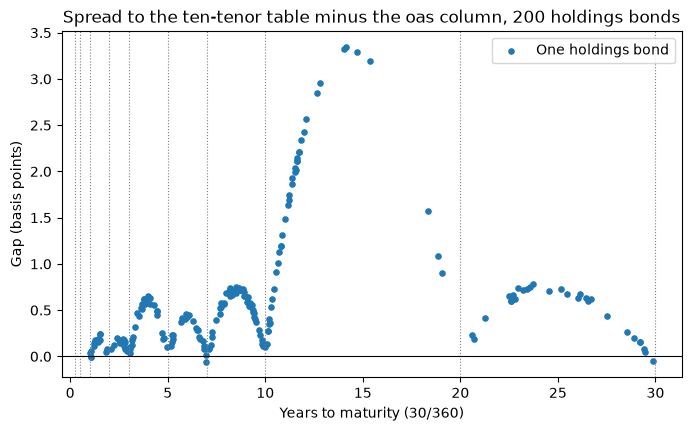

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(holdings["years"], holdings["gap_bp"], s=14, label="One holdings bond")
# the ten tenors, where the straight line touches the curve
for tenor in curve_tenors:
    ax.axvline(tenor, color="grey", linestyle=":", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Spread to the ten-tenor table minus the oas column, 200 holdings bonds")
ax.set_xlabel("Years to maturity (30/360)")
ax.set_ylabel("Gap (basis points)")
ax.legend()
plt.show()

* The gaps fall to zero at the tenors, the dotted lines, and rise between them, most where the tenors are far apart: 10 to 20 years and 20 to 30 years.
* Why the table gives the larger spread: this curve bends, rising quickly at the short end and flattening at the long end. A straight line between two points of a curve that bends this way sits **below** the curve. A lower curve yield leaves a larger spread. Day 11 measured the same distance between the straight line and the smooth curve; today it lands on every bond's spread.
* The four bonds below zero sit within a few weeks of a tenor (1, 7, 30 years), where the line is almost on the curve and the file's rounding to 3 decimals decides the sign. None is more than 0.06 basis points below.

**The interpolation choice moves the spread.** The same bond, the same yield, the same invented curve: 147 or 147.41 basis points for Bezane Finance, and a 3.35 basis point difference for Feskovar Devices. Neither number is wrong. Each is right for the curve it was measured on, so two spreads can only be compared when they were built the same way: the same curve, the same way of reading between its points, and the same count of years.

## 12.7 What to Call the Number

The file calls its column `oas`, short for option-adjusted spread. For these bonds, which are bullets with no options, the file built it as a **yield spread** to the curve at the bond's own maturity: one yield minus another, which is exactly what `spread_to_curve_bp` computes.

On a desk, an option-adjusted spread is measured differently: from a **spot curve** (a zero-coupon yield for each date), each cash flow discounted at its own spot yield plus the spread, with the bond's options modelled. For a bullet with no options it comes out close to the **Z-spread**, the single spread over the spot curve that prices the bond. Spot curves and Z-spreads are beyond this course.

So the course's function is called `spread_to_curve_bp`, never `oas`, and its docstring says it is a yield spread at the same maturity. The column keeps the name the file gave it.

Q. Put the three numbers side by side for the first five bonds.

In [36]:
holdings[["cusip", "issuer", "years", "oas", "spread_formula_bp", "spread_table_bp"]].head().round(4)

,cusip,issuer,years,oas,spread_formula_bp,spread_table_bp
0,99080CAE8,Bezane Finance,5.7167,147,147.0,147.4133
1,99049XAE2,Bezamyth Machinery,2.5472,535,535.0,535.1542
2,99039NAC0,Bezoquil Freight,3.6750,153,153.0,153.5625
3,99039NAG1,Bezoquil Freight,26.5250,218,218.0,218.5985
4,99034IAD4,Bezorin Finance,9.5139,127,127.0,127.3713


* `oas`: the file's column. `spread_formula_bp`: a yield spread to the formula's curve, equal to the column. `spread_table_bp`: a yield spread to the ten-tenor table. Day 13 uses the spread to measure spread duration and DTS.

## Excel Side by Side

Today's Excel in one sheet. Every formula below was typed into Excel and checked on all 200 holdings bonds. The curve goes in A1:B11 (headers in row 1, tenors in A2:A11, yields in B2:B11); each bond takes one row from row 2, with its settlement in D, its maturity in E, and its yield in percent in F.

| Column | Job | Python | Excel, row 2 (tested) | Excel returns for Bezane Finance |
| --- | --- | --- | --- | --- |
| G | Years to maturity | `bondmath.years_to_maturity(as_of, maturity)` | `=YEARFRAC(D2,E2,0)` | 5.716666666666667 |
| L | The 30/360 day count | `bondmath.days_30_360(as_of, maturity)` | `=YEARFRAC(D2,E2,0)*360` | 2058 |
| M | The lookalike | none | `=DAYS360(D2,E2)` | 2058, but 1620 where `YEARFRAC` gives 1621 (from 28 February 2027 to 31 August 2031) |
| H | Curve yield, straight line | `bondmath.interpolate_yield(years, curve_tenors, curve_yields)` | `FORECAST.LINEAR` with `INDEX`/`MATCH` (section 12.3) | 4.131866666666667 |
| I | Spread to the table, bp | `bondmath.spread_to_curve_bp(y, years, curve_tenors, curve_yields)` | `=(F2-H2)*100` | 147.41333333333327 |
| J | Curve yield, the formula | `round(3.55 + 1.05 * (1 - math.exp(-years / 7)), 3)` | `=ROUND(3.55+1.05*(1-EXP(-G2/7)),3)` | 4.136 |
| K | Spread to the formula, bp | `bondmath.spread_to_curve_bp(y, years, [years], [curve])` | `=(F2-J2)*100` | 146.99999999999997 |

Fill row 2 down and column K equals the `oas` column on every bond. The yield in F is typed in percent, as in the file, so the formulas need no `/100`: a spread is a difference of two percents, and `*100` turns it into basis points.

Q. Print the formulas of row 2, ready to type into a sheet.

In [37]:
# the formulas typed into Excel for the first bond, Bezane Finance, in row 2
excel_row_2 = {
    "D2": '=DATE(2026,9,30)',
    "E2": '=DATE(2032,6,18)',
    "F2": '5.606',
    "G2": '=YEARFRAC(D2,E2,0)',
    "H2": '=FORECAST.LINEAR(G2,INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)):INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)+1),INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)):INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)+1))',
    "I2": '=(F2-H2)*100',
    "J2": '=ROUND(3.55+1.05*(1-EXP(-G2/7)),3)',
    "K2": '=(F2-J2)*100',
    "L2": '=YEARFRAC(D2,E2,0)*360',
    "M2": '=DAYS360(D2,E2)',
}
for cell, formula in excel_row_2.items():
    print(f"{cell:4} {formula}")

D2   =DATE(2026,9,30)
E2   =DATE(2032,6,18)
F2   5.606
G2   =YEARFRAC(D2,E2,0)
H2   =FORECAST.LINEAR(G2,INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)):INDEX($B$2:$B$11,MATCH(G2,$A$2:$A$11,1)+1),INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)):INDEX($A$2:$A$11,MATCH(G2,$A$2:$A$11,1)+1))
I2   =(F2-H2)*100
J2   =ROUND(3.55+1.05*(1-EXP(-G2/7)),3)
K2   =(F2-J2)*100
L2   =YEARFRAC(D2,E2,0)*360
M2   =DAYS360(D2,E2)


* Type the curve into A1:B11, these into row 2, and compare each cell with the table above. Then add the next bonds in rows 3 onwards with their own dates and yields, and fill G2:M2 down. The `$` signs keep the curve's range fixed as the formulas move down.

## Save the Day with Git

First, commit today's work. Then today's Git step: **look at how the tests grew**, two ways.

Q. What has changed since the start of the day?

In [38]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 27 +++++++++++++++++++++++++++
 test_bondmath.py | 37 +++++++++++++++++++++++++++++++++++++
 2 files changed, 64 insertions(+)


* ` M` beside both files: 27 lines added to `bondmath.py` and 37 to `test_bondmath.py`. The `??` lines are untracked: the two reference files, copies of the course data, and `__pycache__/`. This work folder has no `.gitignore`; your own folder has had one since day 6.

Q. Commit today's work.

In [39]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add years_to_maturity and spread_to_curve_bp, reproducing the oas column" -m "The spread to the curve feeds spread duration and DTS on day 13."
!git -C "{work}" log --oneline

905c285 Add years_to_maturity and spread_to_curve_bp, reproducing the oas column
f1906a0 Day 11: interpolate_yield on a curve
a298556 End of week 2: dates, accrued, price, duration, convexity
5baded0 End of week 1: price and yield on a coupon date


`git log` with `--` and a file name lists only the commits that changed that file. It answers "when did this file change, and why?" without the noise of the others.

Q. Which commits changed the test file?

In [40]:
# only the commits that touched test_bondmath.py
!git -C "{work}" log --oneline -- test_bondmath.py

905c285 Add years_to_maturity and spread_to_curve_bp, reproducing the oas column
f1906a0 Day 11: interpolate_yield on a curve
a298556 End of week 2: dates, accrued, price, duration, convexity
5baded0 End of week 1: price and yield on a coupon date


* All four: every commit here changed the tests, because every day adds tests. In your own folder, a commit that changed only `bondmath.py` would be left out of this list.

`git diff --stat` with a tag compares that tagged commit with the files as they are now, and counts the lines that changed in each file.

Q. How much has the code grown since the end of week 2?

In [41]:
# the end of week 2 against the files now
!git -C "{work}" diff --stat week2

 bondmath.py      | 57 ++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 66 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 123 insertions(+)


* 57 lines more in `bondmath.py` and 66 more in `test_bondmath.py` since the tag: days 11 and 12, the first two days of week 3. A tag is a name for a commit you will want to compare with later, and `week2` is that name.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the two `%%writefile -a bondmath.py` cells, in sections 12.2 and 12.4, in order, without their first lines. In `test_bondmath.py`, do the same with the three `%%writefile -a test_bondmath.py` cells, in sections 12.2, 12.4, and 12.5. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
...................................                                      [100%]
35 passed in 0.10s
```

If you added the exercise functions of earlier days with their tests, you will see more. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add years_to_maturity and spread_to_curve_bp, reproducing the oas column" -m "The spread to the curve feeds spread duration and DTS on day 13."
```

**Step 5.** Today's Git step on your own history.

```powershell
git log --oneline -- test_bondmath.py
git diff --stat week2
```

Your list of commits is longer than the notebook's: one or more for each day since day 1. If `git diff --stat week2` says `unknown revision`, the tag was never made: run `git log --oneline`, find day 10's commit, and tag it with `git tag week2` followed by its hash.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Say what a spread to the curve measures: the bond's yield minus the curve's yield at the same maturity, times 100, in basis points.
* Count years to maturity on 30/360 with `years_to_maturity`, match Excel's `YEARFRAC` with basis 0, and say where `DAYS360` differs.
* Read a curve at each bond's maturity with `interpolate_yield`, or with `FORECAST.LINEAR` and `INDEX`/`MATCH` in Excel.
* Compute a spread with `spread_to_curve_bp`, and reproduce the holdings file's `oas` column exactly from the curve's formula.
* Measure how far the interpolation choice moves a spread, and say why two spreads are only comparable when built the same way.
* Call the number by its right name: a yield spread to the curve, not an option-adjusted spread or a Z-spread.
* List the commits that changed one file, and measure growth since a tag with `git diff --stat`.

Tomorrow, day 13, asks how much a bond's price moves when its spread moves: spread duration, and DTS, spread duration times the spread you computed today.

## Exercises

The exercises use twenty bonds from `benchmark.csv` that the book does not hold: every 30th bond not held, starting with the first. They are as of the same date, 30 September 2026, and were built on the same invented curve. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It reads the data, picks the twenty bonds, and defines `check`, a small function that marks your answers.

In [42]:
import math
from datetime import date

# the files of the lesson, read again so the exercises stand on their own
holdings = pd.read_csv(data_folder + "holdings.csv")
benchmark = pd.read_csv(data_folder + "benchmark.csv")
ratings = pd.read_csv(data_folder + "ratings.csv")
curve = pd.read_csv(data_folder + "course2_treasury_curve.csv")
curve_tenors = curve["tenor_years"].tolist()
curve_yields = curve["yield_pct"].tolist()
for frame in (holdings, benchmark):
    frame["as_of_date"] = pd.to_datetime(frame["as_of_date"]).dt.date
    frame["maturity"] = pd.to_datetime(frame["maturity"]).dt.date

# every 30th benchmark bond the book does not hold, twenty in all
not_held = benchmark[~benchmark["cusip"].isin(holdings["cusip"])]
twenty = not_held.iloc[::30].head(20).reset_index(drop=True)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


twenty[["cusip", "issuer", "rating", "maturity", "yield_pct", "oas"]]

,cusip,issuer,rating,maturity,yield_pct,oas
0,99001BAB2,Quorvane Energy,BBB,2035-08-08,5.524,122
1,99008IAD6,Osmere Chemicals,BBB-,2032-07-21,5.252,111
2,99016QAG1,Corvolvey Systems,BB+,2028-08-11,5.075,128
3,99025ZAD7,Kezazor Logistics,A,2028-03-14,4.457,71
4,99032GAB4,Queloquil Health,BBB-,2035-02-01,6.031,175
5,99039NAF3,Bezoquil Freight,BB,2035-11-15,5.955,164
6,99047VAF5,Quelundra Power,A,2037-11-24,5.276,89
7,99055DAB3,Mulvebran Logistics,BB,2036-02-25,6.266,194
8,99061JAC0,Morvostrin Finance,BBB+,2038-03-05,5.425,103
9,99071TAA0,Corvoquil Metals,A-,2028-09-27,4.740,93


### Exercise 1

Q. Add `years` and `spread_table_bp` columns to `twenty`: the years to maturity with `bondmath.years_to_maturity`, and the spread to the ten-tenor table with `bondmath.spread_to_curve_bp`. Check, with an `assert`, that the spread to the formula's curve reproduces each bond's `oas` within 1e-9 bp, as in section 12.5. Store the first bond's `spread_table_bp` in **ex1_first_bp** and the largest gap, `spread_table_bp` minus `oas`, in **ex1_largest_gap_bp**.

In [43]:
ex1_first_bp = ...
ex1_largest_gap_bp = ...

In [44]:
check("Exercise 1 first bond's spread", ex1_first_bp, 122.71185185185188)
check("Exercise 1 largest gap", ex1_largest_gap_bp, 1.9533333333333616)

Exercise 1 first bond's spread: not attempted yet
Exercise 1 largest gap: not attempted yet


### Exercise 2

Q. Summarize the twenty spreads to the table by rating bucket: join `ratings` on `rating`, then count the bonds and take the mean `spread_table_bp` of each bucket, in rating order. Store the number of buckets in **ex2_buckets** and the BBB bucket's mean in **ex2_bbb_mean_bp**. Describe the table in one sentence, without a view on any bond or bucket.

In [45]:
ex2_buckets = ...
ex2_bbb_mean_bp = ...

In [46]:
check("Exercise 2 number of buckets", ex2_buckets, 5)
check("Exercise 2 BBB mean spread", ex2_bbb_mean_bp, 151.46441666666666)

Exercise 2 number of buckets: not attempted yet
Exercise 2 BBB mean spread: not attempted yet


### Exercise 3

Q. Add a function to your module. `spread_change_bp(old_spread_bp, new_spread_bp)` returns the change from one spread to another in basis points, new minus old. Write the docstring first: units, convention, and the Excel formula. Then add a test, `test_spread_change_bp_known_case`, with cases you can check by hand. Run pytest, and store the change for Feskovar Devices, from its `oas` to its spread to the table (section 12.6), in **ex3_change**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [47]:
%%writefile -a bondmath.py


# Exercise 3: write spread_change_bp(old_spread_bp, new_spread_bp) below this line

Appending to bondmath.py


In [48]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_spread_change_bp_known_case() below this line

Appending to test_bondmath.py


In [49]:
# run pytest, reload the module, then call your function
ex3_change = ...

In [50]:
check("Exercise 3 change for Feskovar Devices", ex3_change, 3.34800000000007)

Exercise 3 change for Feskovar Devices: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `spread_to_curve_bp` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Yield spread over a curve at the bond's own maturity, in basis points.

Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
maturity, not an option-adjusted spread from a spot curve.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [51]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_spread_to_curve_bp(yield_pct, years, curve_tenors, curve_yields_pct):
    """Yield spread over a curve at the bond's own maturity, in basis points.

Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's own maturity
    curve_yield_pct = bondmath.interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the spread between the bond's yield and the curve
    spread_bp = yield_pct - curve_yield_pct
    return spread_bp

Q. Before you run the next cell: what should the function return for Bezane Finance, the first holdings bond? Section 12.4 has the number.

In [52]:
bond = holdings.iloc[0]
years = bondmath.years_to_maturity(bond["as_of_date"], bond["maturity"])
print(f"Bezane Finance from the assistant's function: {assistant_spread_to_curve_bp(bond['yield_pct'], years, curve_tenors, curve_yields)}")

Bezane Finance from the assistant's function: 1.4741333333333326


Q. Test the function against Excel's spreads before you trust it.

In [53]:
# the test, written from Excel before the code is trusted: Excel's =(F2-H2)*100 for the first five holdings
# bonds, from the sheet of the Excel section (tested in Excel)
excel_spread_bp = {
    "99080CAE8": 147.41333333333327,
    "99049XAE2": 535.1541666666668,
    "99039NAC0": 153.5625,
    "99039NAG1": 218.5984999999999,
    "99034IAD4": 127.37129629629624,
}

for bond in holdings.head(5).itertuples():
    years = bondmath.years_to_maturity(bond.as_of_date, bond.maturity)
    result = assistant_spread_to_curve_bp(bond.yield_pct, years, curve_tenors, curve_yields)
    expected = excel_spread_bp[bond.cusip]
    assert abs(result - expected) < 1e-6, f"{bond.cusip}: {result:.6f} against Excel's {expected:.6f} bp"

print("All five match Excel's spread in basis points")

AssertionError: 99080CAE8: 1.474133 against Excel's 147.413333 bp

Q. The test stops on the first bond that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that all five match. Then store the assistant's spread for Bezane Finance, the first holdings bond, in **ex4_first_bp**.

In [54]:
# fix the function above and run the test again, then store the answer
ex4_first_bp = ...

In [55]:
check("Exercise 4 Bezane Finance spread", ex4_first_bp, 147.41333333333327)

Exercise 4 Bezane Finance spread: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```